In [1]:
# Import QUEER library
import queer
from queer import *
from queer.utils import path_create

import matplotlib.pyplot as plt
import numpy as np

In [2]:
k_points = 800
custom_points = [
    [1/2, 0, 0],   # M
    [0, 0, 0],     # Gamma
    [1/2, 0, 0],   # M
    [1/3, 1/3, 0], # K
    [0, 0, 0],      # Back to Gamma
    [1/3, 1/3, 0] # K
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['M','Γ', 'M', 'K', 'Γ', 'K']

In [3]:
"""
Example script for calculating and plotting electronic band structure
along high-symmetry paths in the Brillouin zone.
"""

# Input files
file_path = "./"
nscf = "nscf.out"
# wout = "NbSe2.wout"
hr = "afm1_hr.dat"

# Number of k points along the path

# Energy axis limits
ylim = [-2, 2]

model = queer.model(hr, file_path, nscf,read_ef=True)

In [4]:
    
# Optional: apply a shift to the Fermi energy if needed
# model = queer(file_path, nscf, wout, hr, shift=0.1)

# Calculate band dispersion along the path
print("Calculating band structure...")  
# bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])



Calculating band structure...
Plotting band structure...


NameError: name 'bands' is not defined

In [ ]:
mesh_3d = mesh_cartesian([150,150,50],factor=2)

In [ ]:
mesh_3d_z = mesh_3d+[0,0,0.32]

In [ ]:
bands_mesh = model.calculate_energy(mesh_3d)


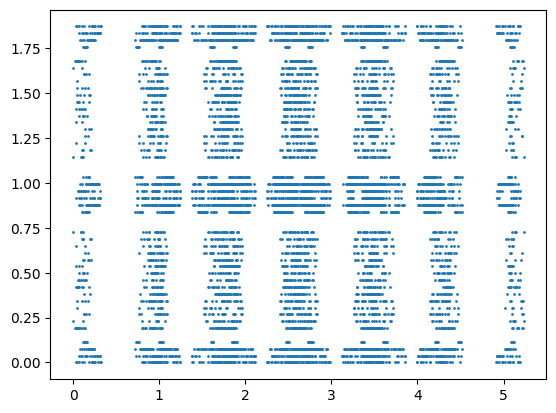

In [ ]:
plt.scatter(df_copy.query('-0.2<=e<= -0.19').y,df_copy.query('-0.2<=e<= -0.19').z,s=1)

In [ ]:
df_copy.query('-0.2<=e<= -0.19')

,kx,ky,kz,x,y,z,e
65253611,0.0,0.966443,0.448980,0.000000,1.686729,0.420358,-0.192140
65253709,0.0,0.993289,0.367347,0.000000,1.733583,0.343929,-0.190701
65253740,0.0,0.993289,1.632653,0.000000,1.733583,1.528574,-0.190480
65253759,0.0,1.006711,0.367347,0.000000,1.757010,0.343929,-0.193560
65253790,0.0,1.006711,1.632653,0.000000,1.757010,1.528574,-0.194364
...,...,...,...,...,...,...,...
69749849,2.0,1.959732,2.000000,3.022942,5.165609,1.872503,-0.193690
69749905,2.0,1.986577,0.204082,3.022942,5.212463,0.191072,-0.197628
69749944,2.0,1.986577,1.795918,3.022942,5.212463,1.681432,-0.197180
69749969,2.0,2.000000,0.775510,3.022942,5.235889,0.726073,-0.197628


In [ ]:
import pandas as pd

In [ ]:
tile_mesh=[]
for i in range(bands_mesh.shape[0]):
    tile_mesh.append(mesh_3d)


In [ ]:
mesh_3d.shape

(1125000, 3)

In [ ]:
mesh_tile = np.array(tile_mesh).reshape(-1,3)

In [ ]:
band_tile = bands_mesh.flatten()

In [ ]:
band_tile.shape

(99000000,)

In [ ]:
mesh_tile.shape

(99000000, 3)

In [ ]:
model.g_vec

array([[1.      , 0.57735 ],
       [0.      , 1.154701]])

In [ ]:
g_vec = np.array([[1.5114710872,0.8726482391,0.0000000000],[0.0000000000,1.7452964781,0.0000000000],[0.0000000000,0.0000000000,0.9362517269]])

In [ ]:

t_mesh = np.dot(g_vec.T, mesh_tile.T).T

In [ ]:
t_mesh

array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.03821436],
       [0.        , 0.        , 0.07642871],
       ...,
       [3.02294217, 5.23588943, 1.79607474],
       [3.02294217, 5.23588943, 1.8342891 ],
       [3.02294217, 5.23588943, 1.87250345]], shape=(99000000, 3))

In [ ]:
mesh_tile

array([[0.        , 0.        , 0.        ],
       [0.        , 0.04081633, 0.        ],
       [0.        , 0.08163265, 0.        ],
       ...,
       [2.        , 1.91836735, 0.        ],
       [2.        , 1.95918367, 0.        ],
       [2.        , 2.        , 0.        ]], shape=(220000, 3))

In [ ]:
df = pd.DataFrame()
df['kx']=mesh_tile.T[0]
df['ky']=mesh_tile.T[1]
df['kz']=mesh_tile.T[2]
df['x']=t_mesh.T[0]
df['y']=t_mesh.T[1]
df['z']=t_mesh.T[2]
df['e']=band_tile

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy = df_copy.query("-5<e<0")

In [ ]:
df_copy['e'] = df_copy['e'] - df_copy['e'].max()

In [ ]:
df_copy.to_csv('limit_shift_scan.dat', float_format='%.3f', sep='\t',index=False)

In [ ]:
df_copy[['x', 'y', 'z', 'e']].to_csv('xyze.dat', float_format='%.3f', sep='\t',index=False)

In [ ]:
df_copy.describe()

,kx,ky,kz,x,y,z,e
count,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07
mean,9.999993e-01,1.000005e+00,9.999994e-01,1.511470e+00,2.617952e+00,9.362512e-01,-2.550562e+00
std,5.813971e-01,5.814223e-01,5.897510e-01,8.787649e-01,1.134368e+00,5.521554e-01,1.272173e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.609359e+00
25%,4.966443e-01,4.966443e-01,4.897959e-01,7.506635e-01,1.733583e+00,4.585723e-01,-3.710928e+00
50%,9.932886e-01,9.932886e-01,9.795918e-01,1.501327e+00,2.612088e+00,9.171445e-01,-2.487858e+00
75%,1.503356e+00,1.503356e+00,1.510204e+00,2.272279e+00,3.502306e+00,1.413931e+00,-1.417476e+00
max,2.000000e+00,2.000000e+00,2.000000e+00,3.022942e+00,5.235889e+00,1.872503e+00,0.000000e+00


In [ ]:
df_copy.

,kx,ky,kz,x,y,z,e
56250000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-4.528996
56250001,0.0,0.0,0.040816,0.000000,0.000000,0.038214,-4.526281
56250002,0.0,0.0,0.081633,0.000000,0.000000,0.076429,-4.514907
56250003,0.0,0.0,0.122449,0.000000,0.000000,0.114643,-4.488668
56250004,0.0,0.0,0.163265,0.000000,0.000000,0.152857,-4.452619
...,...,...,...,...,...,...,...
69749995,2.0,2.0,1.836735,3.022942,5.235889,1.719646,-0.277330
69749996,2.0,2.0,1.877551,3.022942,5.235889,1.757860,-0.326733
69749997,2.0,2.0,1.918367,3.022942,5.235889,1.796075,-0.347955
69749998,2.0,2.0,1.959184,3.022942,5.235889,1.834289,-0.255402


In [ ]:
df_copy.query("-5<e<0").describe()

,kx,ky,kz,x,y,z,e
count,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07,1.335167e+07
mean,9.999993e-01,1.000005e+00,9.999994e-01,1.511470e+00,2.617952e+00,9.362512e-01,-2.941202e+00
std,5.813971e-01,5.814223e-01,5.897510e-01,8.787649e-01,1.134368e+00,5.521554e-01,1.272173e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.999999e+00
25%,4.966443e-01,4.966443e-01,4.897959e-01,7.506635e-01,1.733583e+00,4.585723e-01,-4.101568e+00
50%,9.932886e-01,9.932886e-01,9.795918e-01,1.501327e+00,2.612088e+00,9.171445e-01,-2.878498e+00
75%,1.503356e+00,1.503356e+00,1.510204e+00,2.272279e+00,3.502306e+00,1.413931e+00,-1.808115e+00
max,2.000000e+00,2.000000e+00,2.000000e+00,3.022942e+00,5.235889e+00,1.872503e+00,-3.906398e-01


In [ ]:
df_copy

,kx,ky,kz,x,y,z,e
56250000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-4.528996
56250001,0.0,0.0,0.040816,0.000000,0.000000,0.038214,-4.526281
56250002,0.0,0.0,0.081633,0.000000,0.000000,0.076429,-4.514907
56250003,0.0,0.0,0.122449,0.000000,0.000000,0.114643,-4.488668
56250004,0.0,0.0,0.163265,0.000000,0.000000,0.152857,-4.452619
...,...,...,...,...,...,...,...
69749995,2.0,2.0,1.836735,3.022942,5.235889,1.719646,-0.277330
69749996,2.0,2.0,1.877551,3.022942,5.235889,1.757860,-0.326733
69749997,2.0,2.0,1.918367,3.022942,5.235889,1.796075,-0.347955
69749998,2.0,2.0,1.959184,3.022942,5.235889,1.834289,-0.255402


(-3.0, 0.0)

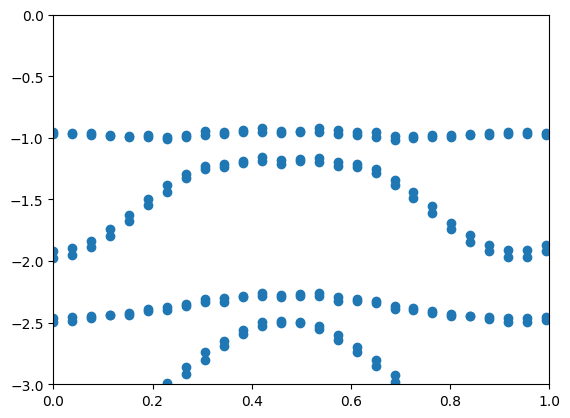

In [ ]:
plt.scatter(df_copy.query("0.49<=ky<=0.5").query("0.0<=kx<=0.01").z,df_copy.query("0.49<=ky<=0.5").query("0.0<=kx<=0.01").e)
plt.xlim(0,1)
plt.ylim(-3,0)

In [ ]:
df_copy[:100]

,kx,ky,kz,x,y,z,e
56250000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,-4.528996
56250001,0.0,0.000000,0.040816,0.0,0.000000,0.038214,-4.526281
56250002,0.0,0.000000,0.081633,0.0,0.000000,0.076429,-4.514907
56250003,0.0,0.000000,0.122449,0.0,0.000000,0.114643,-4.488668
56250004,0.0,0.000000,0.163265,0.0,0.000000,0.152857,-4.452619
...,...,...,...,...,...,...,...
56250095,0.0,0.013423,1.836735,0.0,0.023427,1.719646,-4.453469
56250096,0.0,0.013423,1.877551,0.0,0.023427,1.757860,-4.489737
56250097,0.0,0.013423,1.918367,0.0,0.023427,1.796075,-4.514644
56250098,0.0,0.013423,1.959184,0.0,0.023427,1.834289,-4.526614


In [ ]:
df.query("-5<e<0").to_csv('df_z_limit.dat', float_format='%.3f', sep='\t',index=False)

,kx,ky,kz,x,y,z,e
56250000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-4.919636
56250001,0.0,0.0,0.040816,0.000000,0.000000,0.038214,-4.916921
56250002,0.0,0.0,0.081633,0.000000,0.000000,0.076429,-4.905547
56250003,0.0,0.0,0.122449,0.000000,0.000000,0.114643,-4.879308
56250004,0.0,0.0,0.163265,0.000000,0.000000,0.152857,-4.843259
...,...,...,...,...,...,...,...
69749995,2.0,2.0,1.836735,3.022942,5.235889,1.719646,-0.667970
69749996,2.0,2.0,1.877551,3.022942,5.235889,1.757860,-0.717373
69749997,2.0,2.0,1.918367,3.022942,5.235889,1.796075,-0.738595
69749998,2.0,2.0,1.959184,3.022942,5.235889,1.834289,-0.646042


In [ ]:
df

,kx,ky,kz,x,y,z,e
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-82.845820
1,0.0,0.0,0.040816,0.000000,0.000000,0.038214,-82.847310
2,0.0,0.0,0.081633,0.000000,0.000000,0.076429,-82.844835
3,0.0,0.0,0.122449,0.000000,0.000000,0.114643,-82.850182
4,0.0,0.0,0.163265,0.000000,0.000000,0.152857,-82.843942
...,...,...,...,...,...,...,...
98999995,2.0,2.0,1.836735,3.022942,5.235889,1.719646,7.056571
98999996,2.0,2.0,1.877551,3.022942,5.235889,1.757860,7.205095
98999997,2.0,2.0,1.918367,3.022942,5.235889,1.796075,7.346808
98999998,2.0,2.0,1.959184,3.022942,5.235889,1.834289,7.486152


In [ ]:
df.to_csv('z_scan.dat', float_format='%.3f', sep='\t',index=False)

In [ ]:
`1234567`

In [ ]:
df

,kx,ky,kz,x,y,z,e
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-82.845820
1,0.0,0.0,0.040816,0.000000,0.000000,0.038214,-82.847310
2,0.0,0.0,0.081633,0.000000,0.000000,0.076429,-82.844835
3,0.0,0.0,0.122449,0.000000,0.000000,0.114643,-82.850182
4,0.0,0.0,0.163265,0.000000,0.000000,0.152857,-82.843942
...,...,...,...,...,...,...,...
98999995,2.0,2.0,1.836735,3.022942,5.235889,1.719646,7.056571
98999996,2.0,2.0,1.877551,3.022942,5.235889,1.757860,7.205095
98999997,2.0,2.0,1.918367,3.022942,5.235889,1.796075,7.346808
98999998,2.0,2.0,1.959184,3.022942,5.235889,1.834289,7.486152


In [ ]:
lim_1 = df.query('-1<e<1 ')

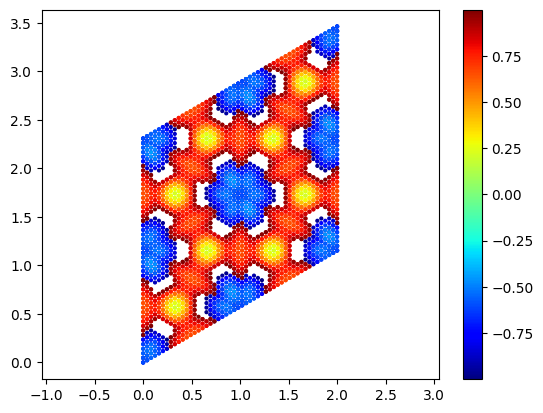

In [ ]:
plt.scatter(lim_1.x,lim_1.y,c=lim_1.e,cmap='jet',s=4)
plt.axis("equal")
plt.colorbar()
plt.show()

In [ ]:
mesh_3d_z = mesh_3d+[0,0,0.31]

In [ ]:
bands_mesh_z = model.calculate_energy(mesh_3d_z)

In [ ]:
tile_mesh_z=[]
for i in range(bands_mesh_z.shape[0]):
    tile_mesh_z.append(mesh_3d_z)


In [ ]:
mesh_tile_z = np.array(tile_mesh_z).reshape(-1,3)

In [ ]:
band_tile_z = bands_mesh_z.flatten()

In [ ]:
g_vec = np.array([[1.5114710872,0.8726482391,0.0000000000],[0.0000000000,1.7452964781,0.0000000000],[0.0000000000,0.0000000000,0.9362517269]])
t_mesh_z = np.dot(g_vec.T, mesh_tile_z.T).T

In [ ]:
df_z = pd.DataFrame()
df_z['kx']=mesh_tile_z.T[0]
df_z['ky']=mesh_tile_z.T[1]
df_z['kz']=mesh_tile_z.T[2]
df_z['x']=t_mesh_z.T[0]
df_z['y']=t_mesh_z.T[1]
df_z['z']=t_mesh_z.T[2]
df_z['e']=band_tile_z

In [ ]:
steps = np.arange(-2,0,0.05)

In [ ]:
df_z.to_csv('0.3_inverse.dat', sep='\t')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df_z = pd.read_csv('0.3_inverse.dat', sep='\t')

In [ ]:
steps = np.arange(-4,0,0.1)

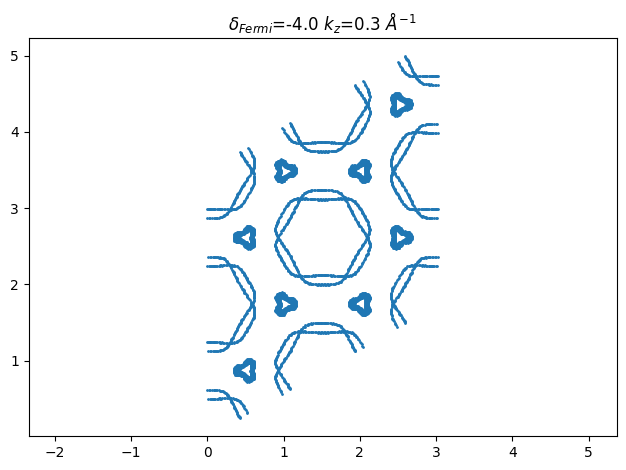

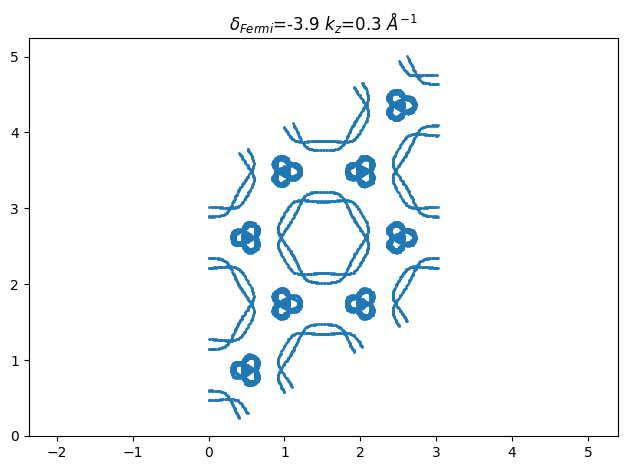

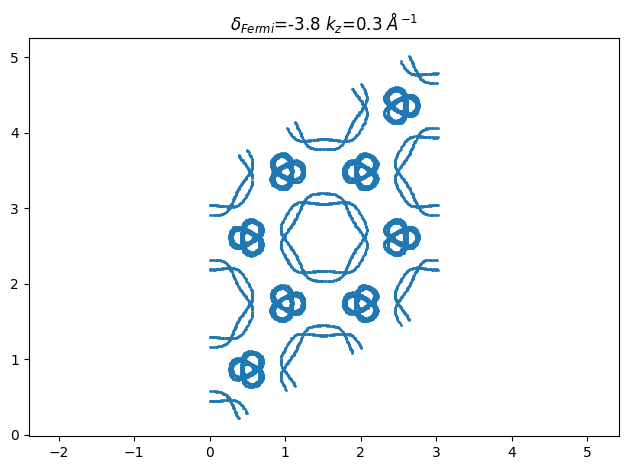

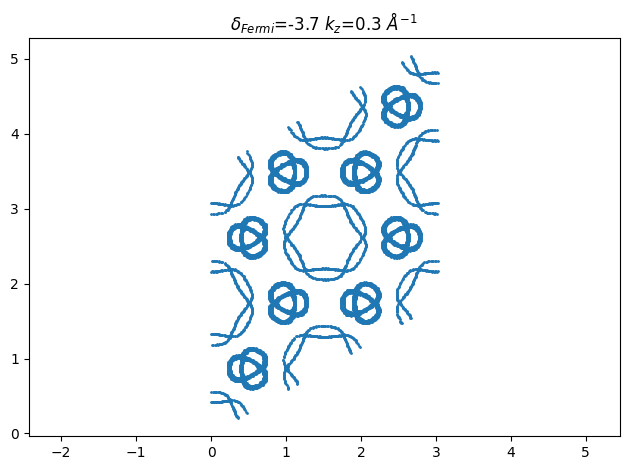

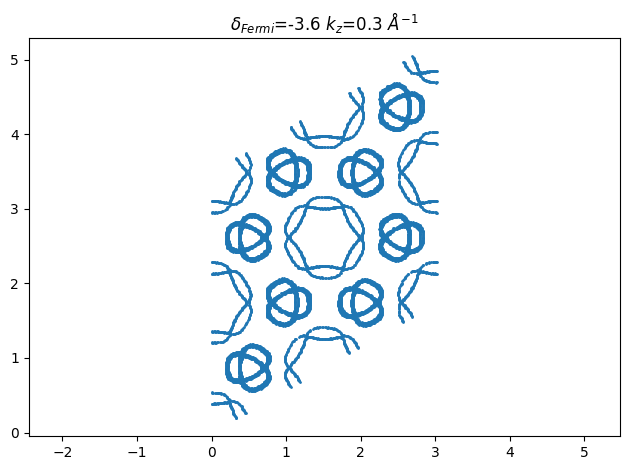

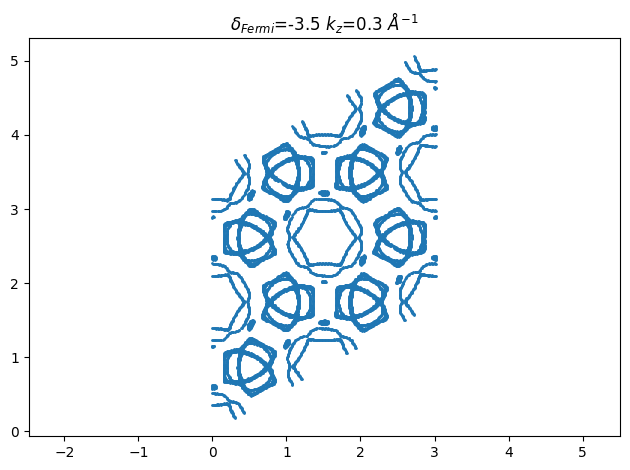

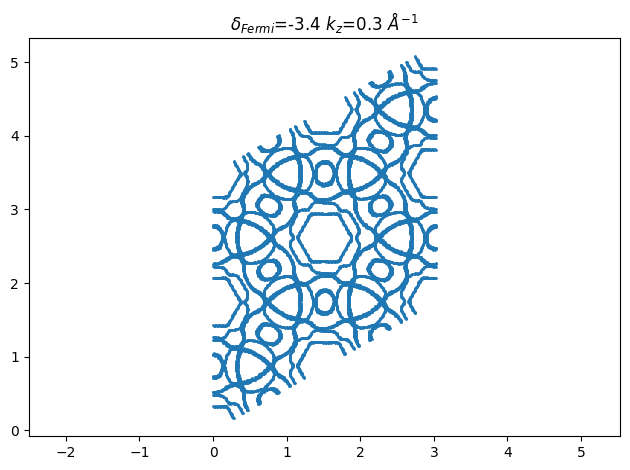

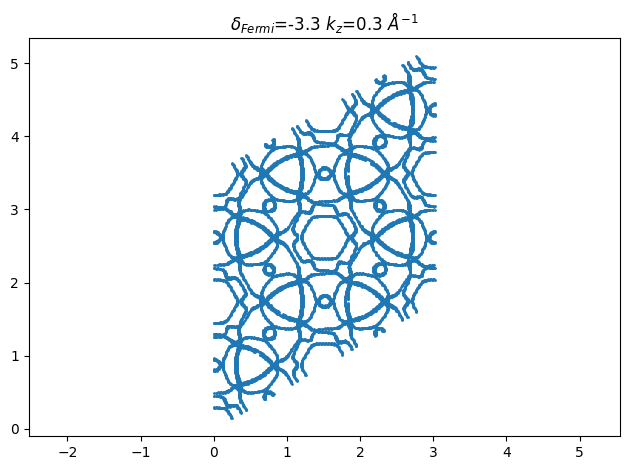

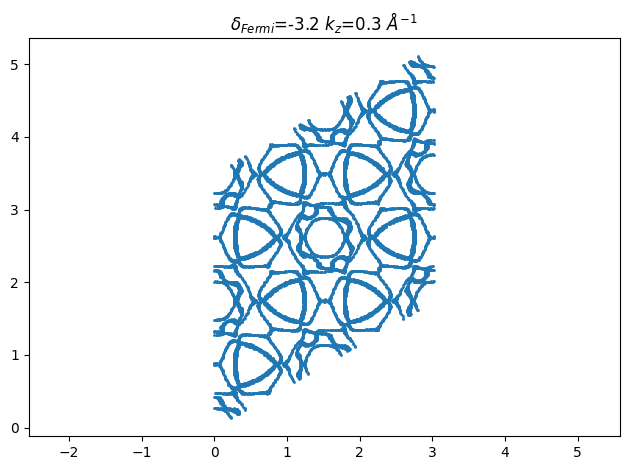

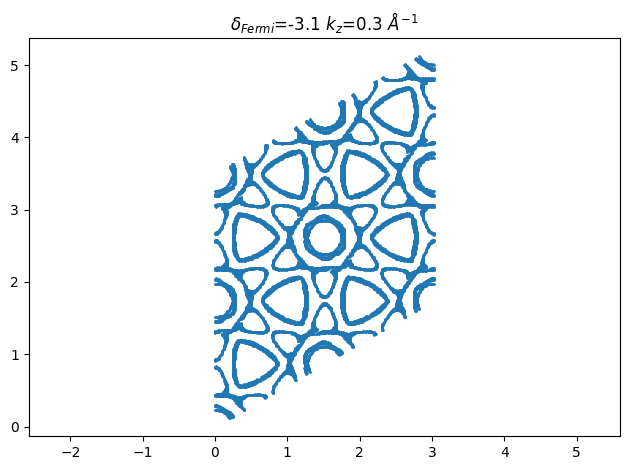

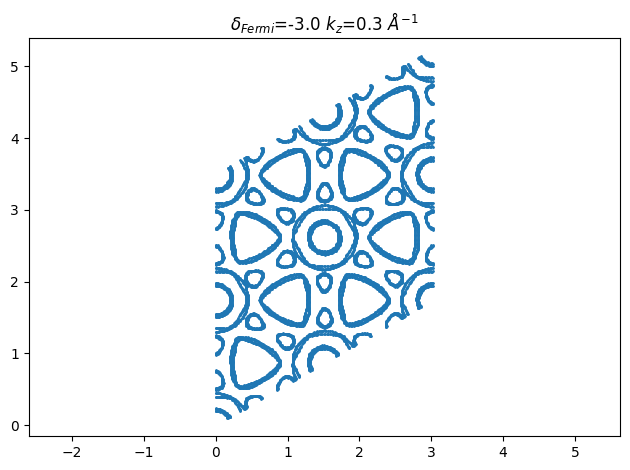

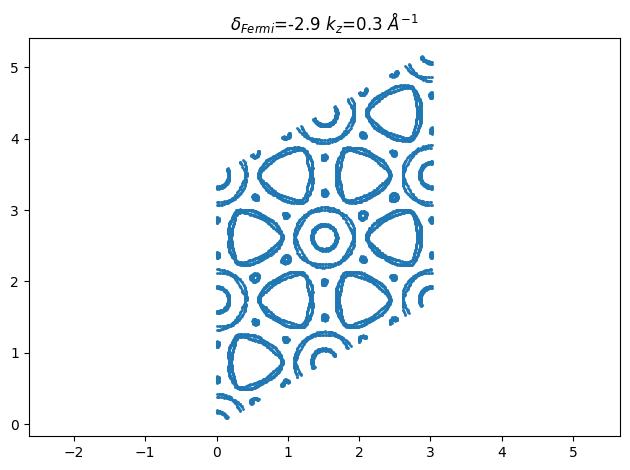

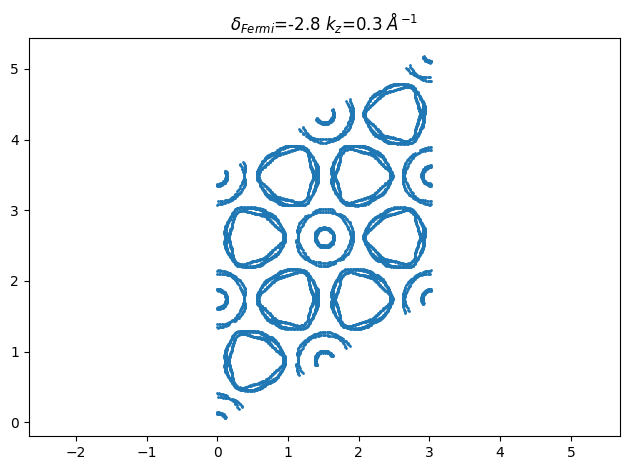

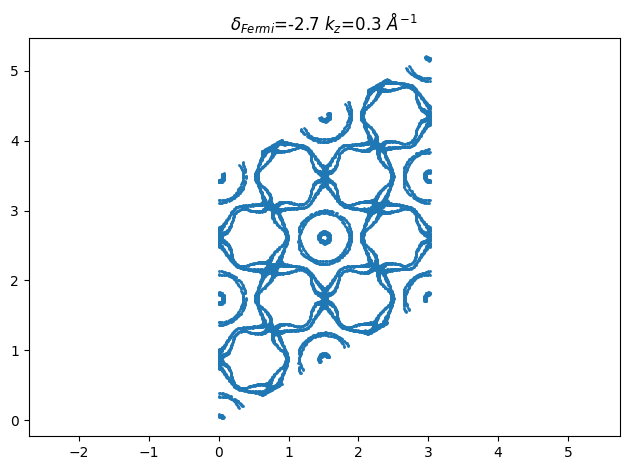

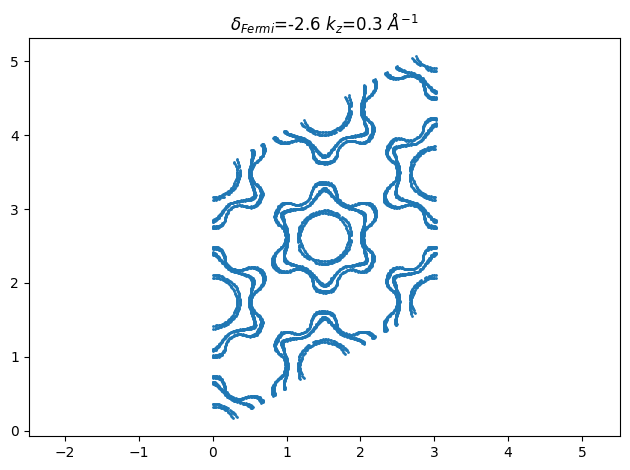

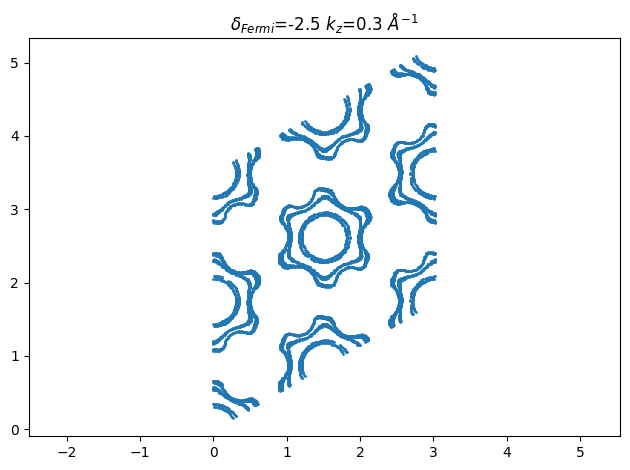

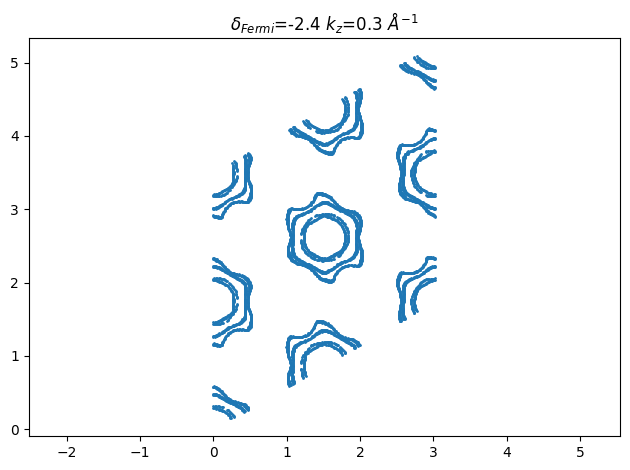

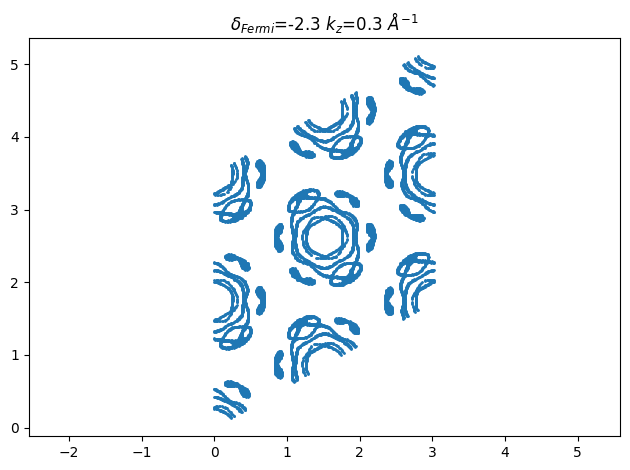

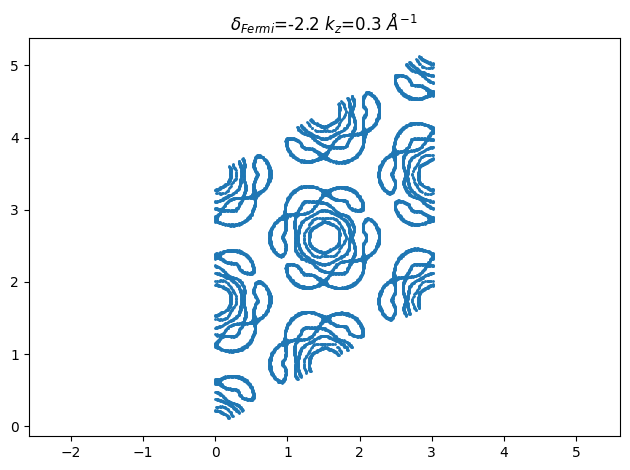

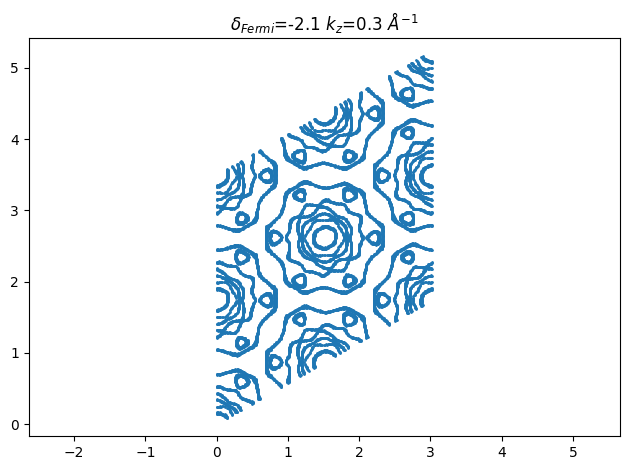

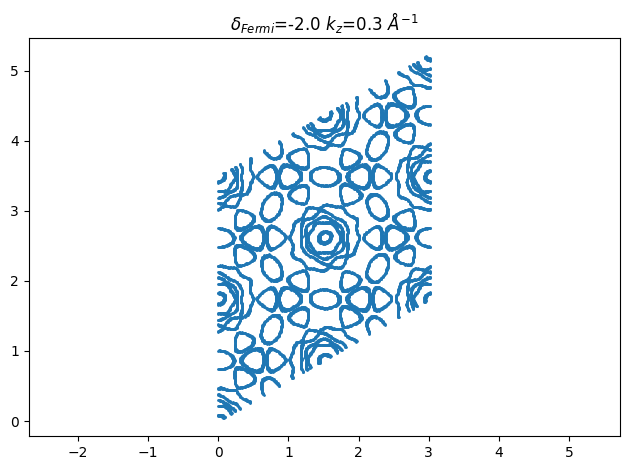

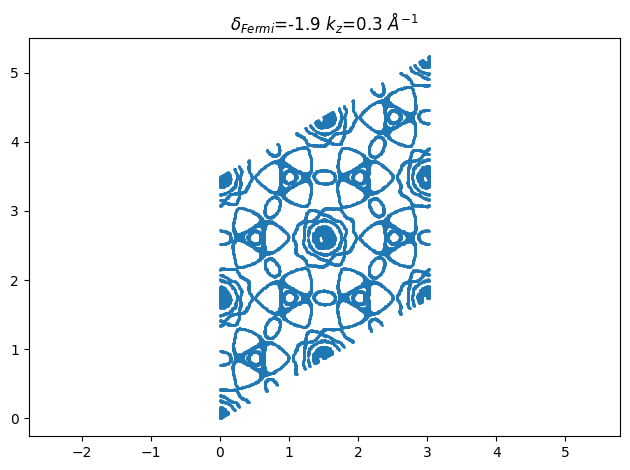

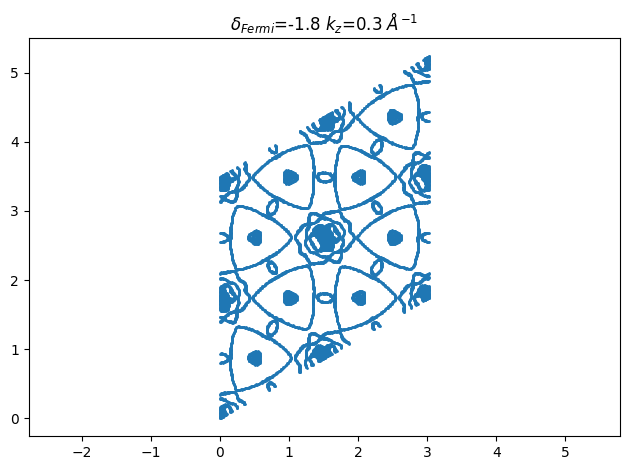

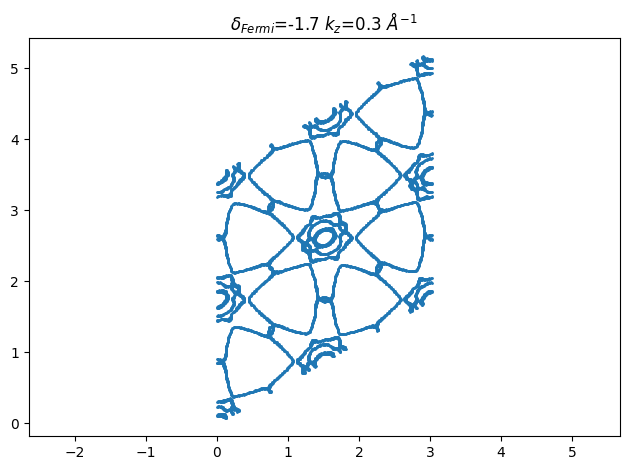

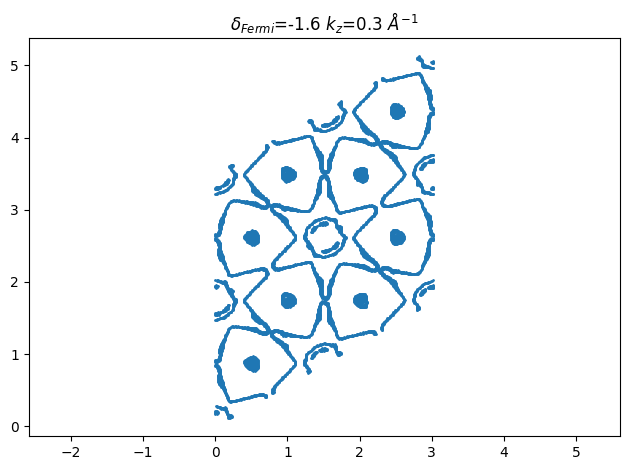

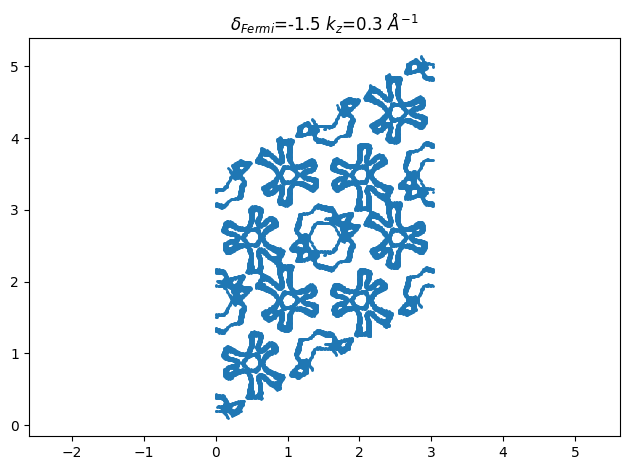

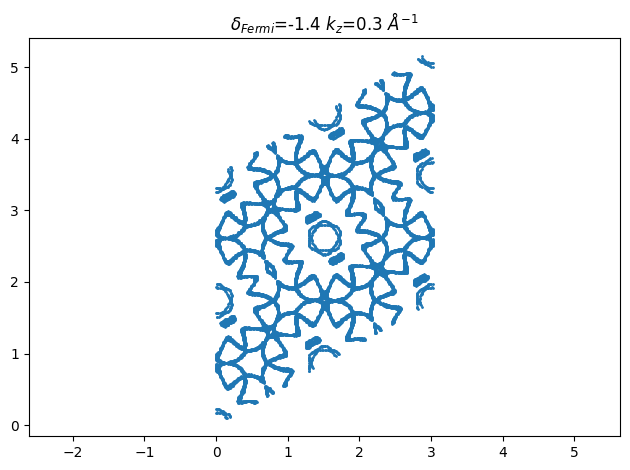

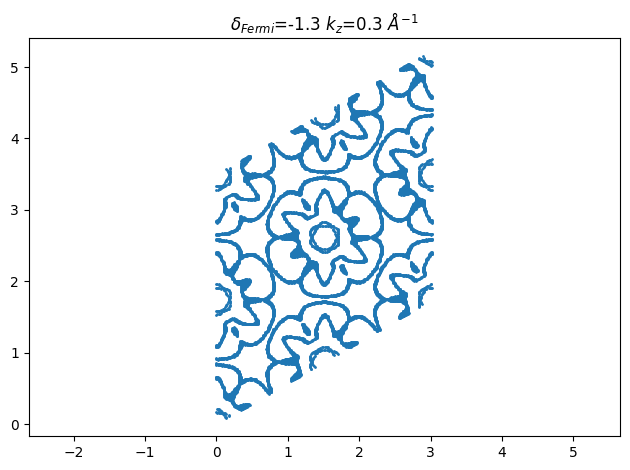

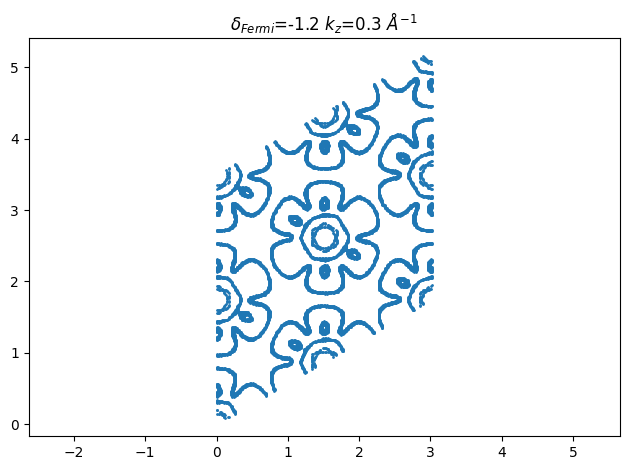

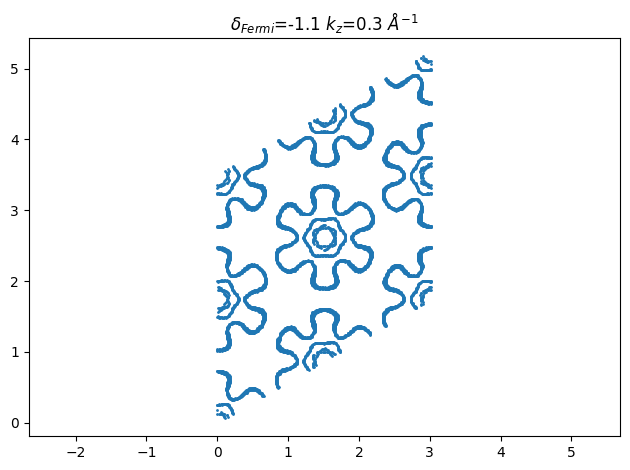

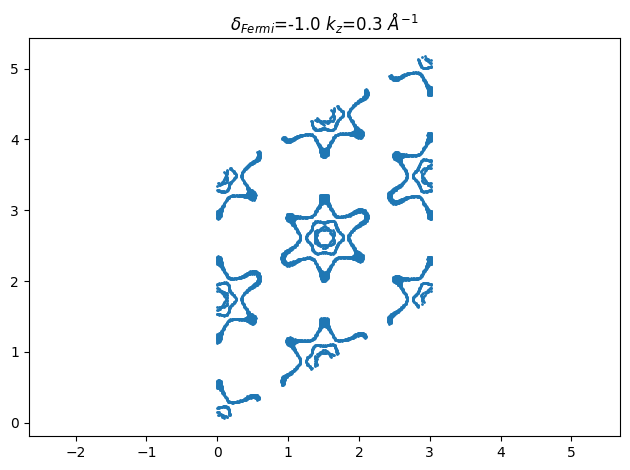

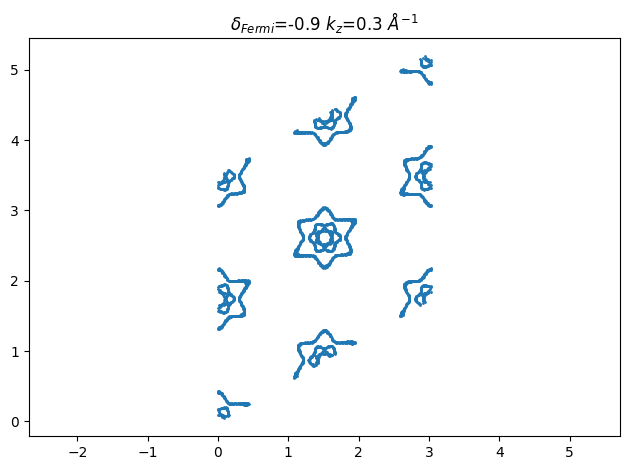

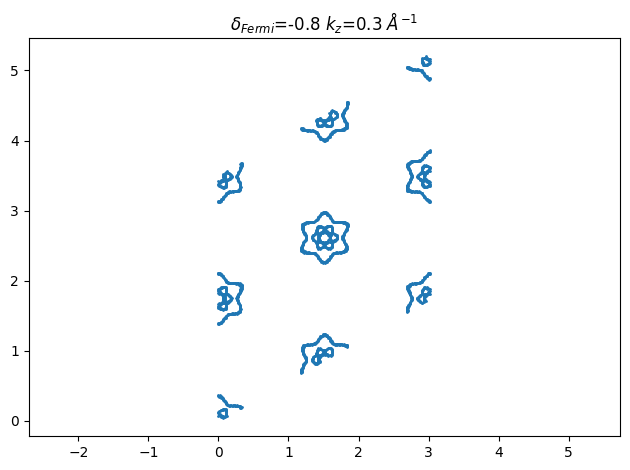

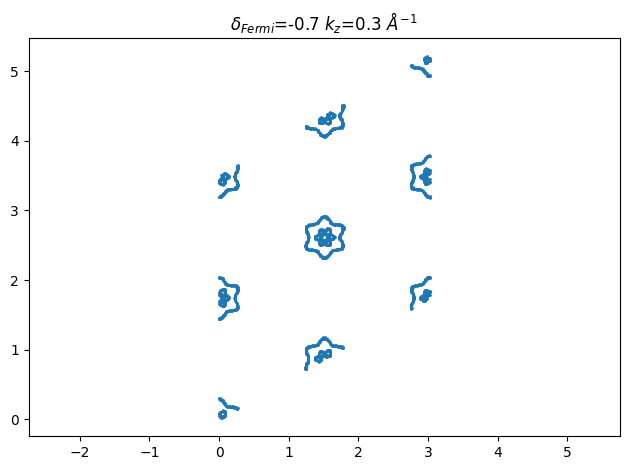

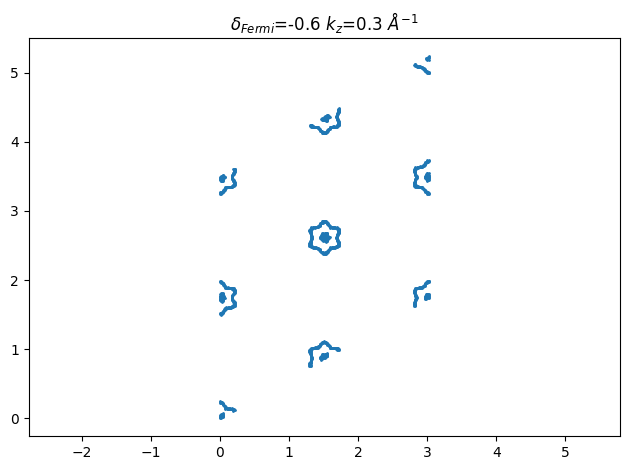

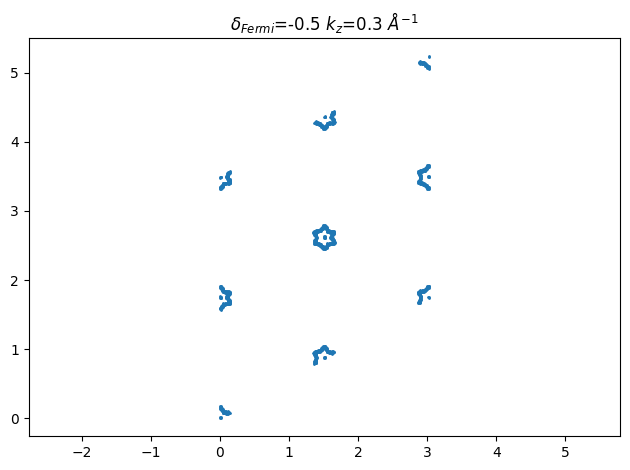

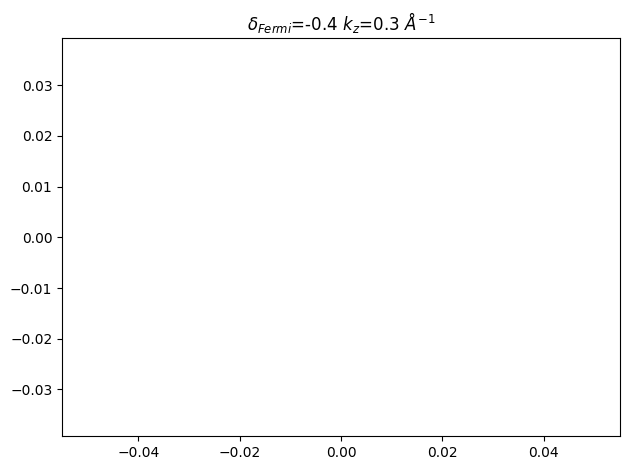

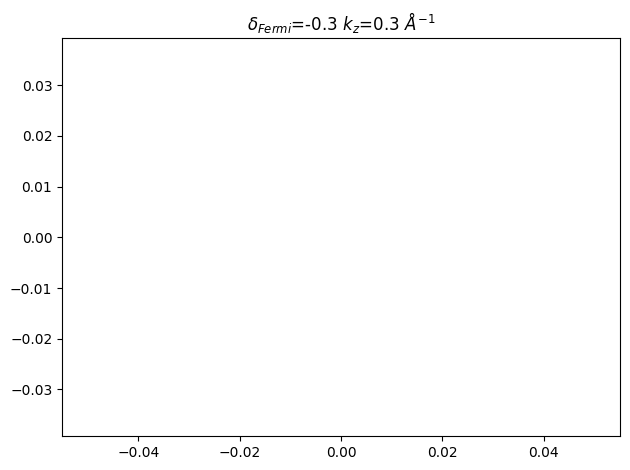

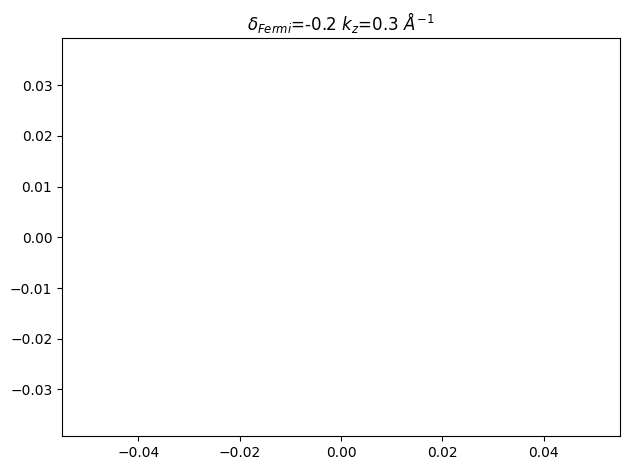

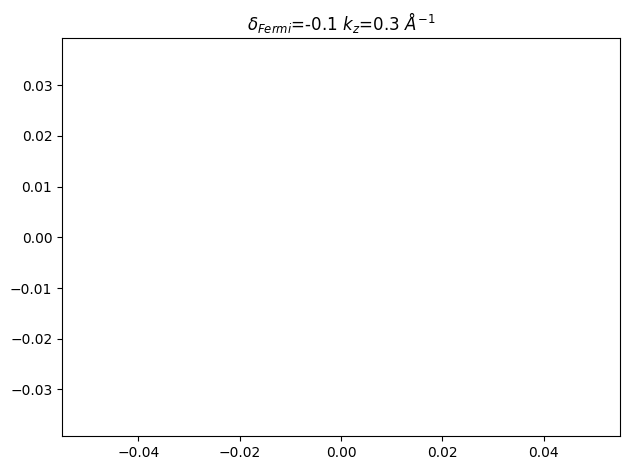

In [ ]:
for i in steps:
    plus = i +0.02
    minus = i - 0.02
    lim_1_z = df_z.query(f'{minus}<e<{plus}')
    plt.scatter(lim_1_z.x,lim_1_z.y,s=1)
    plt.axis("equal")
    plt.title(rf"$\delta_{{Fermi}}$={np.around(i,3)} $k_{{z}}$=0.3 $\AA^{{-1}}$")
    plt.tight_layout()
    plt.savefig(f'./figs/{np.around(i,2)}.png', dpi=300, bbox_inches='tight')
    plt.show()

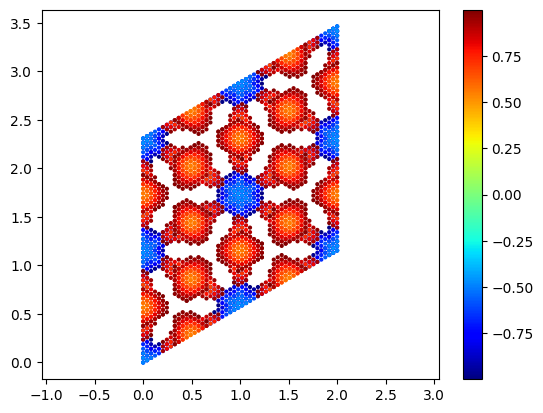

In [ ]:
for i in :
    # lim_1_z = df_z.query(f'-1.<e< ')
    # plt.scatter(lim_1_z.x,lim_1_z.y,c=lim_1_z.e,cmap='jet',s=4)
    # plt.axis("equal")
    # plt.colorbar()
    # plt.show()